### Graph

In [1]:
from database.DBConnector import t_get_unprocessed_chunks_input
from graph.graph_config import create_app

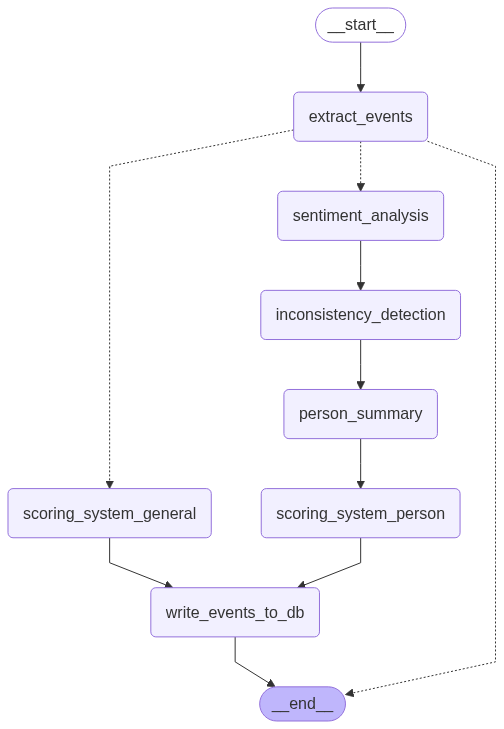

In [2]:
app = create_app()
app

In [3]:
extracted_df = t_get_unprocessed_chunks_input(first_run=False, is_processed=False)
extracted_df

,chunk_id,content,topic,topic_id,article_date,origin_article_id
0,66,The Trump administration is preparing to elimi...,Green energy,1,2025-05-06,24
1,67,.A spokesperson for Energy Star did not return...,Green energy,1,2025-05-06,24
2,68,"It’s hard to green the desert. Take China, or ...",Green energy,1,2025-03-30,25
3,69,Greener pastures: Can ancient eco-engineering ...,Green energy,1,2025-03-30,25
4,70,This Moroccan startup is growing crops in the ...,Green energy,1,2025-03-30,25
...,...,...,...,...,...,...
85,151,Scientists say this invisible gas could seal o...,Green energy,1,2021-08-31,46
86,152,ESG investing — funds that are conscious of co...,Green energy,1,2021-08-16,47
87,153,. Apple’s manufacturing contributed more than ...,Green energy,1,2021-08-16,47
88,154,.“Trying to find the perfect company is imposs...,Green energy,1,2021-08-16,47


66,68 - bad json?
67,69,70,71 - missing person id
not working retries in event_classifier?

209 - usual

In [4]:
elem = extracted_df.loc[extracted_df['chunk_id'] == 70].iloc[0].to_dict()
elem

{'chunk_id': 70,
 'content': 'This Moroccan startup is growing crops in the desertBin Redha said HyveGeo’s product could be used to grow staple crops in the UAE like cowpea, millet, wheat and rice, as well as leafy greens and fruit and vegetables.Dr. Marcella Fernandes de Souza, a postdoctoral researcher at Ghent University, in Belgium, and an expert in algae biotechnology, who is not involved with HyveGeo, told CNN in an email that “it seems they (HyveGeo) are covering all bases to make the soil arable.“However,” she continued, “soil dynamics are very complex and it can take some time for the soil to fully regenerate and regain its health, so I do not know what time frame would be realistic to fully recover this soil.”She also questioned the irrigation requirements for crop cultivation in desert regions.Producing enough microalgae to meet demand and make HyveGeo’s model commercially viable are just two of many challenges the startup faces.“It’s really difficult,” bin Redha conceded. “

In [5]:
res = app.invoke(elem)

In [6]:
res

{'chunk_id': 70,
 'topic': 'Green energy',
 'topic_id': 1,
 'origin_article_id': 25,
 'article_date': Timestamp('2025-03-30 00:00:00'),
 'content': 'This Moroccan startup is growing crops in the desertBin Redha said HyveGeo’s product could be used to grow staple crops in the UAE like cowpea, millet, wheat and rice, as well as leafy greens and fruit and vegetables.Dr. Marcella Fernandes de Souza, a postdoctoral researcher at Ghent University, in Belgium, and an expert in algae biotechnology, who is not involved with HyveGeo, told CNN in an email that “it seems they (HyveGeo) are covering all bases to make the soil arable.“However,” she continued, “soil dynamics are very complex and it can take some time for the soil to fully regenerate and regain its health, so I do not know what time frame would be realistic to fully recover this soil.”She also questioned the irrigation requirements for crop cultivation in desert regions.Producing enough microalgae to meet demand and make HyveGeo’s mod

In [6]:
from graph.states_setup import save_output_as_json
save_output_as_json(res, 'state.json')

### Singe node test

In [1]:
from graph.states_setup import load_state_from_json
from nodes.event_scoring import main

In [2]:
# from graph.prompts import EVENT_CLASSIFICATION_PROMPT
# print(EVENT_CLASSIFICATION_PROMPT)

In [3]:
# print(EVENT_CLASSIFICATION_PROMPT.format(
#     topic=elem['topic'],
#     chunk=elem['content'],
# ))

In [3]:
res = main(load_state_from_json('state.json'))

2025-05-12 00:37:36 - event_scoring             - INFO - N/A - (Stage 3) Event scoring for chunk 70 started
2025-05-12 00:37:36 - event_scoring             - DEBUG - N/A - Processing general_event 1/1 for chunk 70.
2025-05-12 00:37:48 - event_scoring             - DEBUG - 0.000s - Finished parsing model output.
2025-05-12 00:37:48 - event_scoring             - INFO - 12.744s - Successfully calculated event scores
2025-05-12 00:37:48 - event_scoring             - INFO - 12.744s - Chunk 70 processed successfully. Processed 1 general events.


In [5]:
res.person_event

[{'person_name': 'Elon Musk',
  'citation': 'Musk, CEO of Tesla, is a close advisor to Trump despite Biden’s stance on EVs. He’s tasked with a commission cutting government spending.',
  'sentiment': -0.62,
  'sentiment_deviation': 0,
  'stance': 'against',
  'person_summary': 'Elon Musk, despite lacking expertise on green energy, currently opposes it due to his advising Trump and a commission cutting government spending. This contradicts Biden’s EV stance, reflecting a low tendency for change.',
  'relevancy_score': 0.8,
  'contribution_score': 0.7,
  'controversy_score': 0.6,
  'opinion_hotness': 0.71}]

In [4]:
res.general_event

[{'title': 'Desert Crop Startup HyveGeo',
  'description': 'Moroccan startup HyveGeo aims to grow crops in the UAE desert using innovative methods.',
  'relevance_score': 0.9,
  'influence_score': 0.7,
  'novelty_score': 0.6,
  'event_hotness': 0.745}]

In [6]:
res.person_event[0]['opinion_hotness']

0.71

In [7]:
# from database.DBConnector import *

In [8]:
# print(t_get_article_chunk_content(66))

### New test zone

In [4]:
from database.DBConnector import t_get_person_topic_sentiment_history, get_attitude
from nodes.person_summary import get_weighted_sentiment

In [ ]:
get_attitude(fk_topic_id=1, fk_person_id=118)

2025-05-11 14:21:15 - DBConnector               - WARNING - 0.005s - Attitude with fk_topic_id 1 and fk_person_id 118 not found


True

In [14]:
df = t_get_person_topic_sentiment_history(person_id=118, topic_id=1)
df

2025-05-10 22:06:27 - DBConnector          - INFO - 0.006s - Found 7 sentiment records for person_id 118 on topic_id 1


,sentiment_score,article_date
0,-0.60,2024-05-17
1,0.65,2022-10-19
2,0.25,2022-03-18
3,0.85,2020-10-13
4,-0.25,2020-10-10
5,0.60,2020-07-02
6,-0.60,2020-07-02


In [10]:
get_weighted_sentiment(df)

,sentiment_score,article_date,weighted_sentiment
0,-0.60,2024-05-17,-0.687269
1,0.65,2022-10-19,0.726275
2,0.25,2022-03-18,0.268692
3,0.85,2020-10-13,0.858715
4,-0.25,2020-10-10,-0.228126
5,0.60,2020-07-02,0.458640
6,-0.60,2020-07-02,-0.324000


### Old used zone

In [ ]:
# import datetime
# from nodes.inconsistency_detection import get_inconsistent_opinions, get_article

In [ ]:
# df = get_inconsistent_opinions(person_id=118, sentiment_score=-0.6, date=datetime.datetime(2022, 5, 17))

In [ ]:
# get_article(39).loc['article_date']

In [ ]:
# df.to_dict(orient='records')

In [ ]:
# df.loc[:, ]

In [ ]:
# from graph.states_setup import ChunkState
# s = ChunkState(chunk_id=125, topic='Green energy', origin_article_id=39, content='The world is facing a shortage of the minerals needed to make the electric vehicles, wind turbines, solar panels, and other clean energy technologies essential to ending its reliance on fossil fuels.The Paris-based International Energy Agency said in a report published Friday that steep drops in the prices of lithium, cobalt, nickel, and graphite last year were “good news for consumers” but discouraged investment in the mining of those critical minerals.The world is on track meet only 70% of global copper demand and 50% of lithium demand by 2035, the agency added.“The world’s appetite for technologies such as solar panels, electric cars and batteries is growing fast — but we cannot satisfy it without reliable and expanding supplies of critical minerals,” Fatih Birol, the IEA’s executive director, said in a statement.Investment in critical minerals mining grew 10% last year, a rate the agency says is “healthy, but slower than in 2022.”The IEA forecast that investors would need to pour $800 billion into mining projects between now and 2040 to stand a chance of limiting the rise in global temperatures to 1.5 degrees Celsius above pre-industrial levels.RELATED ARTICLE')

In [ ]:
# from nodes.inconsistency_detection import get_inconsistent_opinions
# from datetime import datetime
# get_inconsistent_opinions(person_id=118, sentiment_score=-0.6, date=datetime(year=2024, month=5, day=17))

In [ ]:
# from ast import literal_eval
# state = literal_eval("{'chunk_id': 60, 'topic': 'universal basic income', 'content': 'Entrepreneurs. Freelancers. Gig workers. Consultants. Salespeople.If you freelance, earn commissions, run a small business, or rely on paying clients for a living, your income is likely unpredictable from year to year.But how you manage and allocate the money you make shouldn’t be.Here are some smart ways to ensure you have enough to pay your bills, minimize debt and build savings despite having a fluctuating income.Get real about how much you actually need to cover the essential fixed and variable expenses in your life – housing, food, gas, utilities, debt payments, etc.Do the same for your business expenses.In making your calculations, don’t forget to include taxes, especially since you may need to pay estimated taxes quarterly, so you should have money set aside to do that to avoid penalties.Besides income taxes, you also will be subject to self-employment taxes to fund Social Security and Medicare, and if you have hired employees, you’ll need to provide the employer portion of those taxes for them, too.To be able to take full advantage of any tax deductions that may be available to you, keep very good records of receipts for payments and purchases you make.And don’t forget about buying and paying for disability insurance. “You are your asset. And if you can’t work, you have no income,” said certified financial planner Lazetta Braxton, co-CEO of 2050 Wealth Partners.Your chosen field, the seasonal ebbs and flows in your line of work and what differentiates you from your competition will influence how much revenue you can generate in a year.Project a realistic range of how much money you can bring in, and base your financial strategies around the lower end of that range if you want to be safe, said certified financial planner Kerry O’Brien, who founded BeingFIT Financial.Braxton also recommends, especially if you’re just starting a business, that you have a related side gig to augment your income. That might include teaching an e-course, doing paid speaking engagements or using UpWork to find an occasional project.“Use your human capital. Leverage it in ways that are not overconsuming,” she said.Try to set aside six to 12 months’ worth of expenses for those months when you’re not bringing in much income.If you have a spouse making a steady income who is supporting your household, you may not need more than six months set aside, O’Brien said', 'general_event': [{'title': 'Financial Planning for Fluctuating Income', 'description': 'Advice on budgeting and saving strategies for freelancers, gig workers, and entrepreneurs with unpredictable income streams. Includes considerations for taxes and disability insurance.'}], 'person_event': [{'person_name': 'Lazetta Braxton (2050 Wealth Partners)', 'citation': '\"You are your asset. And if you can’t work, you have no income,\" said certified financial planner Lazetta Braxton, co-CEO of 2050 Wealth Partners.'}], 'origin_article_id': 22}")
# state

In [1]:
from database.DBConnector import *

In [2]:
t_get_article_chunk_content(80)

2025-05-13 19:38:30 - DBConnector               - DEBUG - 0.053s - Article chunk found with chunk_id: 80
2025-05-13 19:38:30 - DBConnector               - DEBUG - 0.007s - Article found with article_id: 28


'. “The sooner we can deliver drop-in solutions for regular-way agriculture, the better off we’re going to be.”Iyris has integrated SecondSky into flexible polyfilm, which is used for polytunnels, plastic sheets for rigid greenhouses, and netting.Polyfilm is typically replaced every three to five years, said Keppler, and can be easily swapped in. Iyris says that unlike some traditional interventions to block heat, such as applying white chalk to plastic film, its additive does not negatively impact the plastic’s lifespan.The company has partnered with plastics producers such as SABIC in Saudi Arabia, Hyma Plastic in Egypt and Armando Alvarez in Spain to manufacture and distribute coverings containing its heat-blocking additive, and it says to date 4.5 million square meters of its materials have been sold.Vincent Martin, director of the Office of Innovation at the UN Food and Agriculture Organization, told CNN via email that “a number of agritech start-ups have emerged in recent years t

In [13]:
t_get_unprocessed_chunks_input()

,chunk_id,content,topic,topic_id,article_date,origin_article_id
0,66,The Trump administration is preparing to elimi...,Green energy,1,2025-05-06,24
1,67,.A spokesperson for Energy Star did not return...,Green energy,1,2025-05-06,24
2,68,"It’s hard to green the desert. Take China, or ...",Green energy,1,2025-03-30,25
3,69,Greener pastures: Can ancient eco-engineering ...,Green energy,1,2025-03-30,25
4,70,This Moroccan startup is growing crops in the ...,Green energy,1,2025-03-30,25
...,...,...,...,...,...,...
85,151,Scientists say this invisible gas could seal o...,Green energy,1,2021-08-31,46
86,152,ESG investing — funds that are conscious of co...,Green energy,1,2021-08-16,47
87,153,. Apple’s manufacturing contributed more than ...,Green energy,1,2021-08-16,47
88,154,.“Trying to find the perfect company is imposs...,Green energy,1,2021-08-16,47
